---
title: Transmission Dither Locking, Pound-Drever-Hall Michelson, and Fabry-Perot Michelson  - Homework 04 Submission
date: 2025-04-06
authors:
  - name: Caroline Capuano
    orcid: 0000-0002-3888-314X
    affiliations:
      - Syracuse University
numbering:
  heading_1: true
  heading_2: true
  heading_3: true
---

This is the fourth homework assignment for *Lasers and Optomechanics* at Syracuse University.\
**It is due Monday, April 6th, 2026 by 5 pm**

**<span style="color:#ff5555;">You will need to complete the questions in this jupyter notebook and submit it via `gitlab`</span>**


# Transmitted Field Dither Locking

In class, we investigated dither locking using the reflected field $E_\mathrm{refl}$ from a Fabry-Perot cavity.

In this problem, investigate whether it is possible to use $E_\mathrm{trans}$ to hold lock.


## Plot of Fabry-Perot $E_\mathrm{trans}$ versus $E_\mathrm{trans}$

Plot both $E_\mathrm{refl}$ and $E_\mathrm{trans}$ over a span of $\phi \in \left[ -\dfrac{\pi}{2},\dfrac{3\pi}{2} \right]$

Do you notice anything different about the resonance points?

$$E_{\text{refl}} = \dfrac{r_1 - r_2 e^{-i\phi}}{1-r_1 r_2 e^{i\phi}} E_in$$

$$E_{\text{trans}} = \dfrac{t_1 t_2 e^{-\dfrac{i\phi}{2}}}{1-r_1 r_2 e^{i\phi}}$$

I am assuming $r_1 = r_2$, and $t_1=t_2$


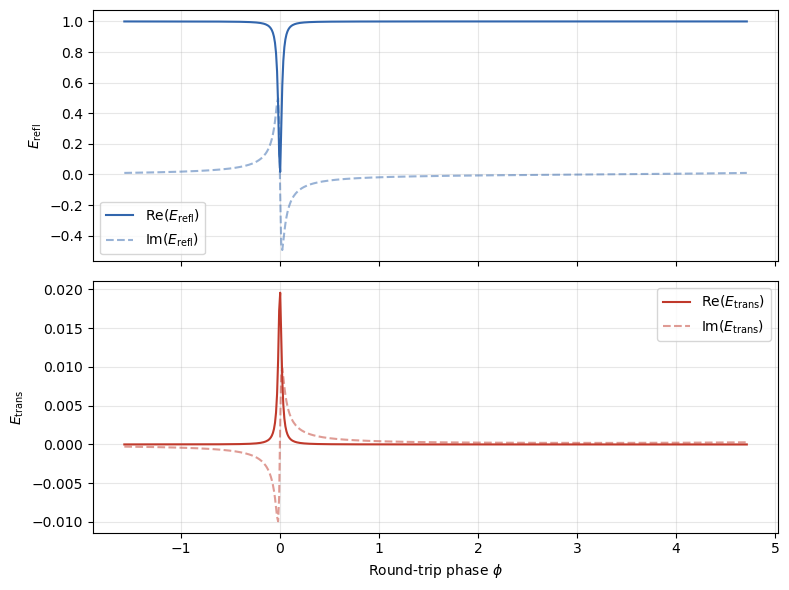

In [31]:
import numpy as np
import matplotlib.pyplot as plt

r = 0.99
t2 = t1 = 1 - r**2
N = 600
phi = np.linspace(-np.pi/2, 3*np.pi/2, N)

denom = 1 - r**2 * np.exp(1j*phi)

E_refl = (r-r*np.exp(1j*phi))/ denom
E_trans = t2 * t1 * np.exp(1j*phi/2) / denom

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

ax1.plot(phi, E_refl.real, color='#3266ad', label=r'$\mathrm{Re}(E_\mathrm{refl})$')
ax1.plot(phi, E_refl.imag, color='#3266ad', linestyle='--', alpha=0.5, label=r'$\mathrm{Im}(E_\mathrm{refl})$')
ax1.set_ylabel(r'$E_\mathrm{refl}$')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(phi, E_trans.real, color='#c0392b', label=r'$\mathrm{Re}(E_\mathrm{trans})$')
ax2.plot(phi, E_trans.imag, color='#c0392b', linestyle='--', alpha=0.5, label=r'$\mathrm{Im}(E_\mathrm{trans})$')
ax2.set_ylabel(r'$E_\mathrm{trans}$')
ax2.set_xlabel(r'Round-trip phase $\phi$')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Question: **Do you notice anything different about the resonance points?**

Both have resonance points around 0.

$\mathrm{Re}\!\left(E_{\mathrm{trans}}\right)$ reaches a maximum

$\mathrm{Re}\!\left(E_{\mathrm{refl}}\right)$ goes to about zero



## Total $E_\mathrm{trans}$ with end-mirror moduation 

If we apply an end-mirror modulation $\Delta x \cos(\omega t)$ to our Fabry-Perot cavity, 
what is the total $E_\mathrm{trans}(t)$ field?

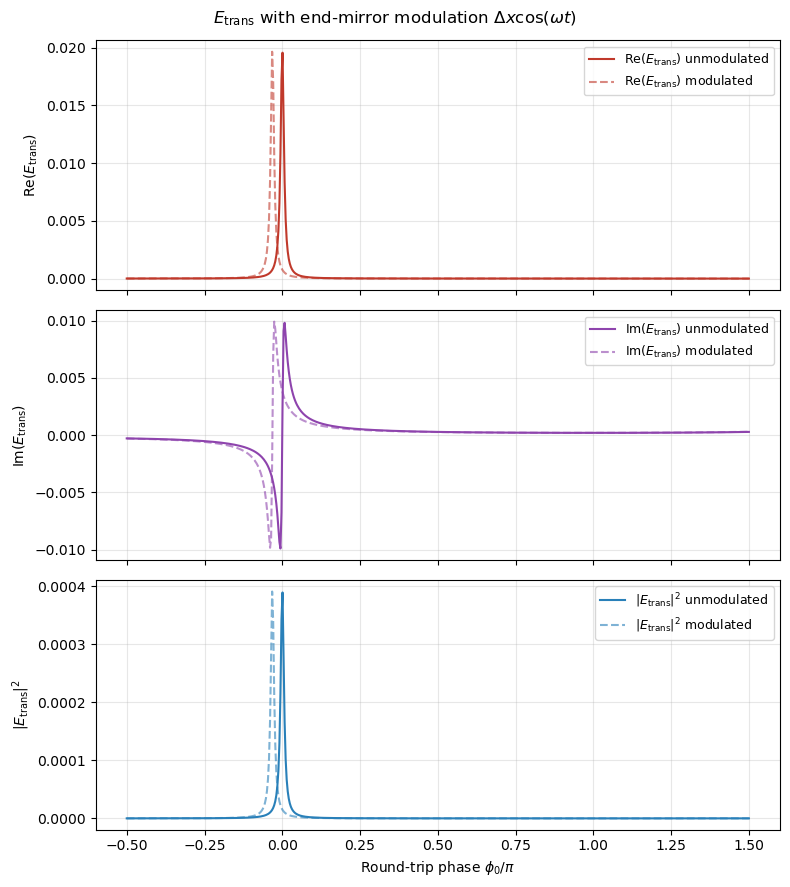

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

r = 0.99
t2 = t1 = 1 - r**2
N = 600
phi0 = np.linspace(-np.pi/2, 3*np.pi/2, N)
delta_phi = 0.1  # modulation depth β

phi_mod = phi0 + delta_phi  # one sideband

denom0 = 1 - r**2 * np.exp(1j * phi0)
denom_mod = 1 - r**2 * np.exp(1j * phi_mod)

E_trans0 = t2 * t1 * np.exp(1j * phi0 / 2) / denom0
E_trans_mod = t2 * t1 * np.exp(1j * phi_mod / 2) / denom_mod

I_trans0 = np.abs(E_trans0)**2
I_trans_mod = np.abs(E_trans_mod)**2

fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)

# E field real part
axes[0].plot(phi0/np.pi, E_trans0.real, color='#c0392b', label=r'$\mathrm{Re}(E_\mathrm{trans})$ unmodulated')
axes[0].plot(phi0/np.pi, E_trans_mod.real, color='#c0392b', linestyle='--', alpha=0.6, label=r'$\mathrm{Re}(E_\mathrm{trans})$ modulated')
axes[0].set_ylabel(r'$\mathrm{Re}(E_\mathrm{trans})$')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# E field imaginary part 
axes[1].plot(phi0/np.pi, E_trans0.imag, color='#8e44ad', label=r'$\mathrm{Im}(E_\mathrm{trans})$ unmodulated')
axes[1].plot(phi0/np.pi, E_trans_mod.imag, color='#8e44ad', linestyle='--', alpha=0.6, label=r'$\mathrm{Im}(E_\mathrm{trans})$ modulated')
axes[1].set_ylabel(r'$\mathrm{Im}(E_\mathrm{trans})$')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# Intensity
axes[2].plot(phi0/np.pi, I_trans0, color='#2980b9', label=r'$|E_\mathrm{trans}|^2$ unmodulated')
axes[2].plot(phi0/np.pi, I_trans_mod, color='#2980b9', linestyle='--', alpha=0.6, label=r'$|E_\mathrm{trans}|^2$ modulated')
axes[2].set_ylabel(r'$|E_\mathrm{trans}|^2$')
axes[2].set_xlabel(r'Round-trip phase $\phi_0 / \pi$')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

plt.suptitle(r'$E_\mathrm{trans}$ with end-mirror modulation $\Delta x \cos(\omega t)$', fontsize=12)
plt.tight_layout()
plt.show()

## Calculate the total transmitted power $P_\mathrm{trans}(t)$

Calculate $P_\mathrm{trans}(t) = |E_\mathrm{trans}(t)|^2$

You may set $\Delta x^2 = 0$ for simplicity in the calculations.  
You should end up with only DC and 1$\omega$ terms.

You may leave this power term in a general form if you wish, 
but you must be clear what each of the contributing fields are.

Original Function

$$E_{\text{trans}} = \dfrac{t_1 t_2 e^{-\dfrac{i\phi}{2}}}{1-r_1 r_2 e^{i\phi}}$$

Mirror Modulation makes $\phi = \phi_0 + \dfrac{4 \pi \Delta x}{\lambda} \cos{\omega t}$:

$$E_{\text{trans}} = E_0 \frac{t^2 e^{i(\phi_0 + \dfrac{4 \pi \Delta x}{\lambda} \cos{\omega t})/2}}{1 - r^2 e^{i(\phi_0 + \dfrac{4 \pi \Delta x}{\lambda} \cos{\omega t})}}$$


Keeping the equation simple:

$$E_{\text{trans}} = E_0 \frac{t^2 e^{i\phi/2}}{1 - r^2 e^{i\phi}}$$

Where $\phi$ is now $\phi = \phi_0 + \Delta \phi \cos{\omega t} = \phi_0 + \dfrac{4 \pi \Delta x}{\lambda} \cos{\omega t}$


$$P_{\text{trans}} = |E_{\text{trans}}|^2$$

$$P_{\text{trans}} = | E_0 \frac{t^2 e^{i\phi/2}}{1 - r^2 e^{i\phi}}|^2 = P_0 \dfrac{t^4 |e^{i\phi/2}|^2}{|1 - r^2 e^{i\phi}|^2}$$

Simplifying $|e^{i\phi/2}|^2 = 1$

$$P_{\text{trans}} =  P_0 \dfrac{t^4 }{|1 - r^2 e^{i\phi}|^2}$$

Expanding the denominator:

$$|1 - r^2 e^{i\phi}|^2 = (1 - r^2 e^{i\phi})(1 - r^2 e^{-i\phi}) = 1-r^2e^{i\phi}-r^2e^{-i\phi}+r^4 = 1+r^4-2r^2\cos{\phi}$$

So the power is 

$$P_{\text{trans}} = P_0 \dfrac{t^4}{1+r^4-2r^2\cos{\phi}} = P_0 \dfrac{t^4}{1+r^4-2r^2\cos{(\phi_0 + \Delta \phi \cos{\omega t})}}$$

Approximation using Taylor Expansion:


$$P_{\text{trans}(\phi_0 + \Delta \phi \cos{\omega t})} \approx P(\phi_0) + \Delta \phi \cos{\omega t} P^\prime(\phi_0) $$

Computing derivative:

$$P^\prime(\phi_0)= \dfrac{-2r^2t^4\sin{\phi}}{(1+r^4 -2r\cos{\phi})^2}$$

Plugging this together:

$$P_{\text{trans}(\phi_0 + \Delta \phi \cos{\omega t})} \approx P(\phi_0) + \Delta \phi \cos{\omega t} \dfrac{-2r^2t^4\sin{\phi}}{(1+r^4 -2r\cos{\phi})^2} $$









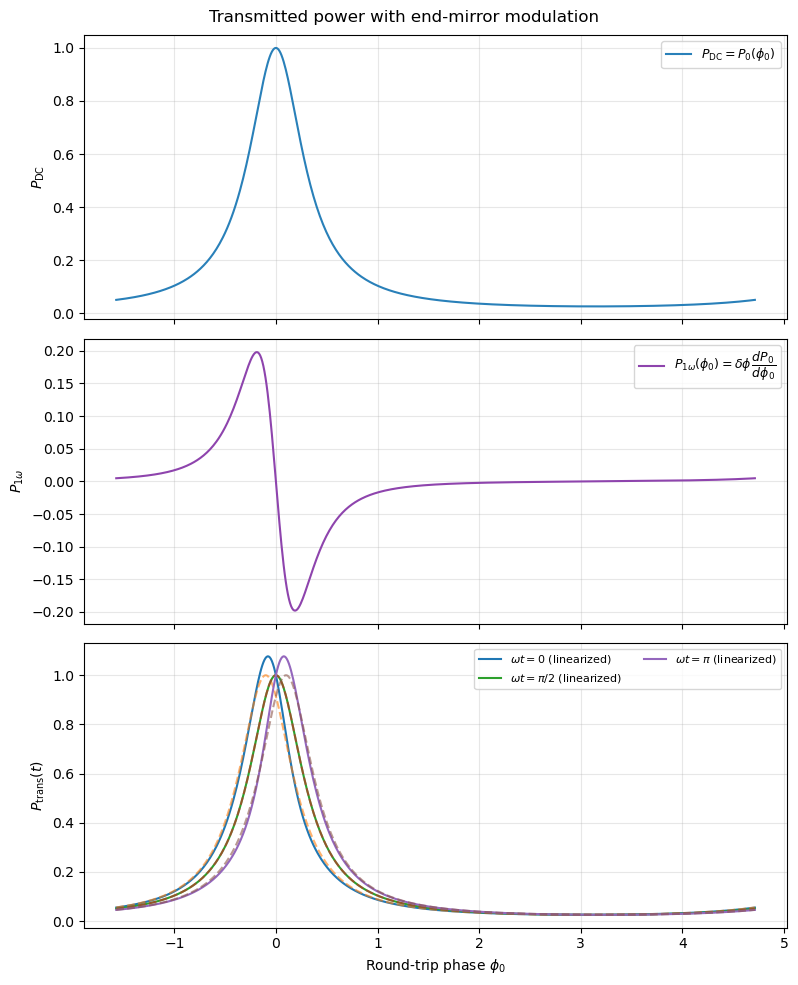

In [33]:
import numpy as np
import matplotlib.pyplot as plt


r = 0.85
t2 = 1 - r**2 
N = 600
phi0 = np.linspace(-np.pi/2, 3*np.pi/2, N)

delta_phi = 0.1 # small modulation

# unmodulated
D0 = 1 + r**4 - 2*r**2*np.cos(phi0)
P0 = t2**2 / D0

# derivative
dP0_dphi = -(2 * r**2 * t2**2 * np.sin(phi0)) / D0**2

wt_list = [0, np.pi/2, np.pi]
labels = [r'$\omega t = 0$', r'$\omega t = \pi/2$', r'$\omega t = \pi$']


fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# DC power
axes[0].plot(phi0, P0, color='#2980b9', label=r'$P_{\rm DC} = P_0(\phi_0)$')
axes[0].set_ylabel(r'$P_{\rm DC}$')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].plot(
    phi0,
    delta_phi * dP0_dphi,
    color='#8e44ad',
    label=r'$P_{1\omega}(\phi_0)=\delta\phi\,\dfrac{dP_0}{d\phi_0}$'
)
axes[1].set_ylabel(r'$P_{1\omega}$')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

for wt, lab in zip(wt_list, labels):
    # first-order approx
    P_lin = P0 + delta_phi * np.cos(wt) * dP0_dphi

    phi_t = phi0 + delta_phi * np.cos(wt)
    D_exact = 1 + r**4 - 2*r**2*np.cos(phi_t)
    P_exact = t2**2 / D_exact

    axes[2].plot(phi0, P_lin, label=lab + ' (linearized)')
    axes[2].plot(phi0, P_exact, '--', alpha=0.6)

axes[2].set_ylabel(r'$P_{\rm trans}(t)$')
axes[2].set_xlabel(r'Round-trip phase $\phi_0$')
axes[2].legend(fontsize=8, ncol=2)
axes[2].grid(alpha=0.3)

plt.suptitle(r'Transmitted power with end-mirror modulation', fontsize=12)
plt.tight_layout()
plt.show()

## Calculate the transmitted power demodulated at $\omega$ 
Calculate the demodulated term $P_\mathrm{trans}(\omega) = P^I_\mathrm{trans}(\omega) + i P^Q_\mathrm{trans}(\omega)$.
This should be directly proportional to $\Delta x$.

I will calculate the demodulated terms by following these equations (taken from class notes):

$$P_I = \dfrac{1}{2\pi} \int^{2\pi}_0 P(t)\cos{\omega t} d(\omega t)$$

$$P_Q = \dfrac{1}{2\pi} \int^{2\pi}_0 P(t)\sin{\omega t} d(\omega t)$$

Using this equation from the previous section $P_{\text{trans}(\phi_0 + \Delta \phi \cos{\omega t})} \approx P_0(\phi_0) + \Delta \phi \cos{\omega t} P^\prime(\phi_0)$

$$P_{I, \text{trans}} = \dfrac{1}{2\pi} \int^{2\pi}_0 (P(\phi_0) + \Delta \phi \cos{\omega t} P^\prime(\phi_0))\cos{\omega t} d(\omega t) = \dfrac{1}{2\pi} [P_0(\phi_0) \int^{2\pi}_0 \cos{\theta} d(\theta) + \Delta \phi P^\prime(\phi_0)\int^{2\pi}_0 \cos^2{\theta} d(\theta)] = \dfrac{1}{2} \Delta \phi P^\prime(\phi_0)$$


$$P_{I, \text{trans}} = \dfrac{1}{2} \Delta \phi \dfrac{-2r^2t^4\sin{\phi}}{(1+r^4 -2r\cos{\phi})^2} = \dfrac{-P_{\text{in}} \Delta \phi r^2t^4\sin{\phi_0}}{(1+r^4 -2r\cos{\phi})^2}$$

$$P_{Q, \text{trans}} = \dfrac{1}{2\pi} \int^{2\pi}_0 (P(\phi_0) + \Delta \phi \cos{\omega t} P^\prime(\phi_0))\sin{\omega t} d(\omega t) = \dfrac{1}{2\pi} [P(\phi_0) \int^{2\pi}_0 \sin{\theta} d\theta + \Delta \phi P^\prime (\phi_0) \int^{2\phi}_0 \cos{\theta}\sin{\theta} d\theta]$$

$$P_{Q, \text{trans}} = 0$$

So the final demodulated term $P_\mathrm{trans}(\omega) = P^I_\mathrm{trans}(\omega) + i P^Q_\mathrm{trans}(\omega)$ is the following:

$$\boxed{P_\mathrm{trans}(\omega) = \dfrac{-P_{\text{in}} \Delta \phi r^2t^4\sin{\phi_0}}{(1+r^4 -2r\cos{\phi})^2}}$$




## Plot the length to transmitted power function phase sweep
Plot the real and imaginary parts of $\dfrac{P_\mathrm{trans}(\omega)}{\Delta x}$ over $\phi \in \left[ -\dfrac{\pi}{2},\dfrac{3\pi}{2} \right]$

Choosing some low to moderate finesse cavity parameters, 
plot your derived function $\dfrac{P_\mathrm{trans}}{\Delta x}(\omega)$ as a function of carrier phase $\phi$.

Let the cavity parameters be
$$L = 1~\mathrm{m}\\ P_\mathrm{in} = 1~\mathrm{W}\\ T_1 = 0.3\\ T_2 = 0.3\\ \lambda = 1064~\mathrm{nm}\\ \omega = 2 \pi (100~\mathrm{Hz})$$


$$P_\mathrm{trans}(\omega) = \dfrac{-P_{\text{in}} \Delta \phi r^2t^4\sin{\phi_0}}{(1+r^4 -2r\cos{\phi})^2}$$

where $\Delta \phi = \dfrac{4\phi \Delta x}{\lambda}$. Plugging this into the top expression and solving for $\dfrac{P_\mathrm{trans}(\omega)}{ \Delta x}$:

$$P_\mathrm{trans}(\omega) = \dfrac{-P_{\text{in}} \dfrac{4\phi \Delta x}{\lambda} r^2t^4\sin{\phi_0}}{(1+r^4 -2r\cos{\phi})^2}$$

$$\dfrac{P_\mathrm{trans}(\omega)}{\Delta x} = \dfrac{-4\phi r^2t^4\sin{\phi_0}P_{\text{in}}}{\lambda(1+r^4 -2r\cos{\phi})^2}$$



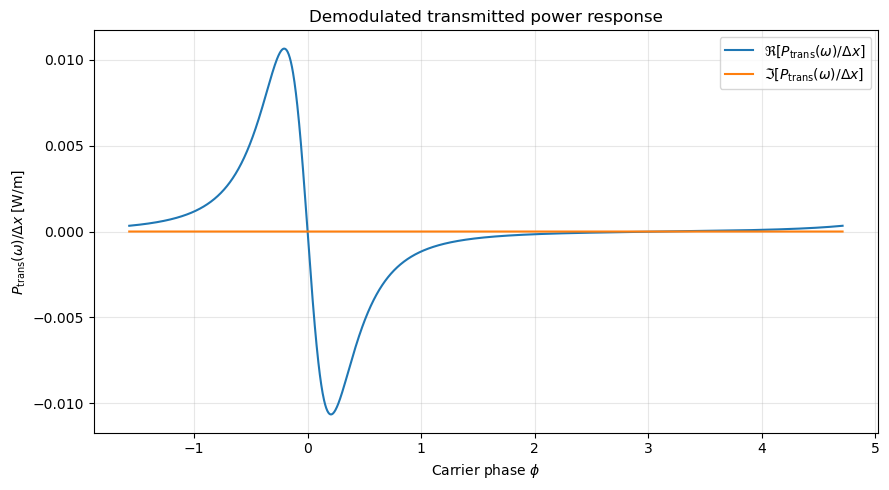

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# cavity parameters
L = 1 #[m]
P_in = 1 #[W]
T_1 = 0.3
T_2 = 0.3
wavelength = 1064 #[nm]
omega = 2 * np.pi * 100 # modulation frequency 
c = 3e8 #[m/s]


r1 = np.sqrt(1 - T_1)
r2 = np.sqrt(1 - T_2)
R = r1 * r2
k = 2 * np.pi / wavelength
tau = L / c

# phase range
phi = np.linspace(-np.pi/2, 3*np.pi/2, 2000)


z = np.exp(-2j * omega * tau)

D0 = 1 + R**2 - 2 * R * np.cos(phi)
D1 = 1 - 2 * R * np.cos(phi) * z + R**2 * z**2

P_over_dx = -(2 * k * P_in * T_1 * T_2 * R * np.sin(phi) * z) / (D0 * D1)

plt.figure(figsize=(9, 5))
plt.plot(phi, np.real(P_over_dx), label=r'$\Re[P_{\rm trans}(\omega)/\Delta x]$')
plt.plot(phi, np.imag(P_over_dx), label=r'$\Im[P_{\rm trans}(\omega)/\Delta x]$')
plt.xlabel(r'Carrier phase $\phi$')
plt.ylabel(r'$P_{\rm trans}(\omega)/\Delta x \; [\mathrm{W/m}]$')
plt.title(r'Demodulated transmitted power response')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Plot the length to transmitted power transfer function

Plot your transfer function magnitude and phase $\dfrac{P_\mathrm{trans}}{\Delta x}(\omega)$ as a function of frequency $f = \omega / (2\pi)$.

Use the same cavity parameters as above, but allow $f \in [3 \times 10^3, 3 \times 10^8]~\mathrm{Hz}$, while setting $\phi = 1^{\circ}$.

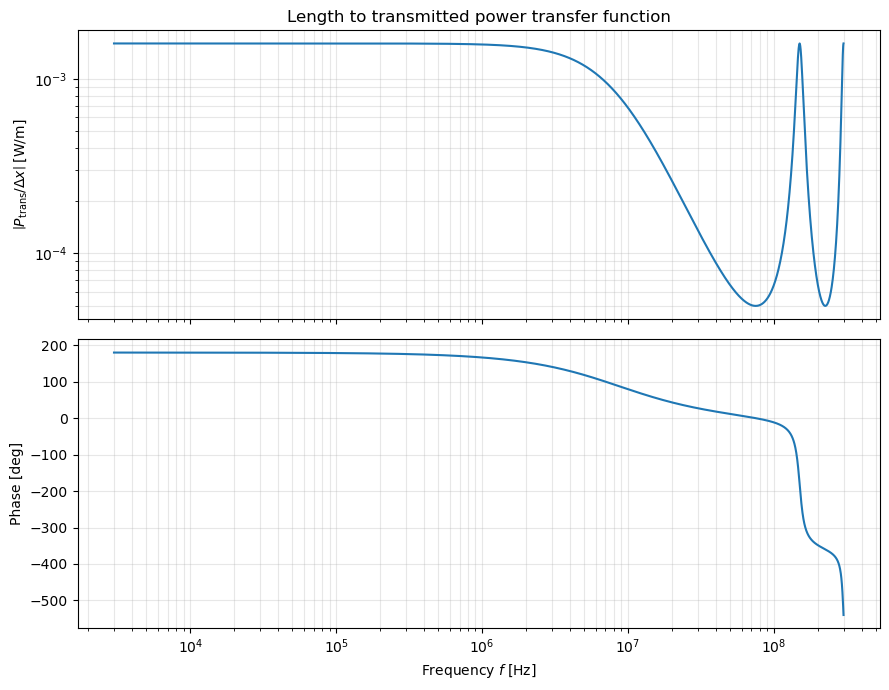

In [35]:
phi = np.deg2rad(1)  
phi_deg = 1.0  # degrees
phi = np.deg2rad(phi_deg)

f = np.logspace(np.log10(3e3), np.log10(3e8), 4000)
omega = 2 * np.pi * f


z = np.exp(-2j * omega * tau)

D0 = 1 + R**2 - 2 * R * np.cos(phi)
D1 = 1 - 2 * R * np.cos(phi) * z + R**2 * z**2

P_over_dx = -(2 * k * P_in * T_1 * T_2 * R * np.sin(phi) * z) / (D0 * D1)

# Magnitude and phase
mag = np.abs(P_over_dx)
phase_deg = np.unwrap(np.angle(P_over_dx)) * 180 / np.pi


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

ax1.loglog(f, mag)
ax1.set_ylabel(r'$\left|P_{\rm trans}/\Delta x\right|\;[\mathrm{W/m}]$')
ax1.set_title(r'Length to transmitted power transfer function')
ax1.grid(True, which='both', alpha=0.3)

ax2.semilogx(f, phase_deg)
ax2.set_xlabel(r'Frequency $f\;[\mathrm{Hz}]$')
ax2.set_ylabel(r'Phase [deg]')
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()



# Pound-Drever-Hall Michelson

In-class we went over the Pound-Drever-Hall (PDH) Fabry-Perot interferometer.

Now we'll try to apply the same technique lock a Michelson interferometer to it's carrier dark fringe.

Below is a diagram of a Michelson with carrier at $\omega_0$, 
and two RF phase sidebands created by an electro-optic modulator (EOM)
oscillating at $\Omega$ to create two frequencies $\omega_0 \pm \Omega$.\
Our goal is to calculate the PDH error signal $\epsilon_\mathrm{PDH}$ as a function of the carrier phase offset $\phi_d$ and RF sideband frequency $\Omega$.

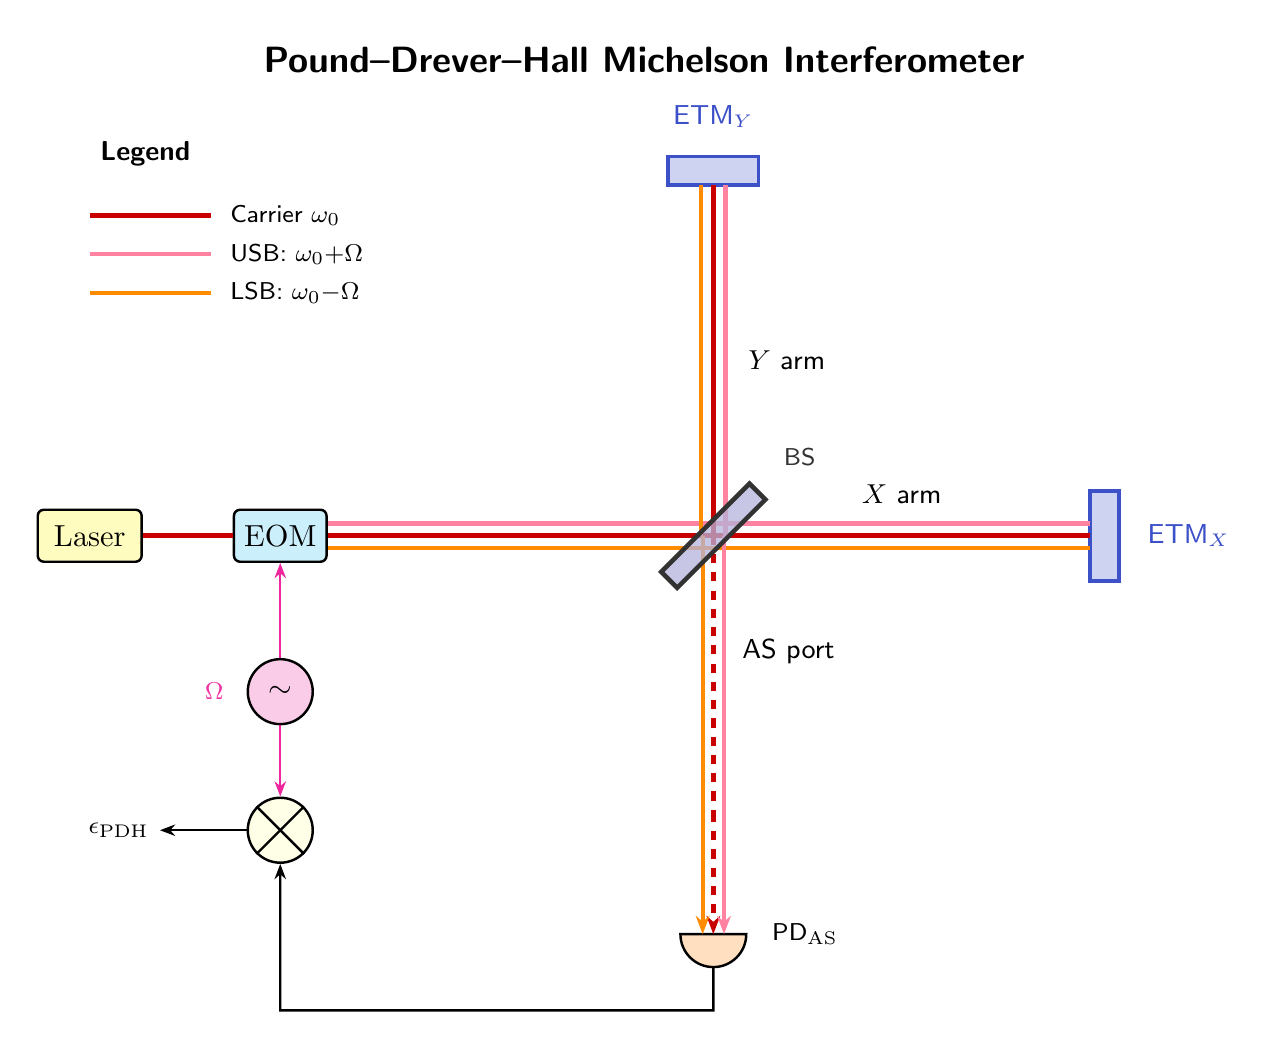

## Calculate the total dark field $E_{as}(t)$.

Calculate the full field expression $E_{as}(t)$ at the dark port of the interferometer.

There should be three contributions, one from carrier and two from the RF phase sidebands injected alongside the carrier.

Let the modulation depth of the RF sideband be $\Gamma$.\
Let the carrier differential phase be $\phi_d = \omega_0 (L_x - L_y) / c$,\
and the RF phase differential phase be $\varphi_d = \Omega (L_x - L_y) / c$.\

What happens to our phases and $E_{as}(t)$ if $L_x = L_y$ exactly?

*Hint: The RF sidebands will experience a phase shift of $\phi_d \pm \varphi_d$ as it transmitted through the interferometer*

The RF sidebands experience a phase shift of $\phi_d \pm \varphi_d$ after being transmitted through the interferometer.

$$\phi_d = \dfrac{\omega_0(L_x - L_y)}{c} = \dfrac{\omega_0 \Delta L}{c}$$

$$\varphi_d = \dfrac{\Omega(L_x - L_y)}{c} = \dfrac{\Omega \Delta L}{c}$$

After the EOM, the input E field will experience phase modulations:

$$E_{\text{in}} = E_o e^{i\omega_0 t} (1+i \Gamma \cos{\Omega t})$$

Substituting $\cos{\Omega t} = \dfrac{e^{i\Omega t}+e^{-i\Omega t}}{2}$

$$E_{\text{in}} = E_o e^{i\omega_0 t} +\dfrac{i E_0}{2}e^{i(\omega_0 + \Omega)t} +\dfrac{i E_0}{2}e^{i(\omega_0 - \Omega)t}$$

The field at the AS port is the difference of the two arm contributions 

$$E_{\text{as}} = \dfrac{E_\omega}{2} (e^{i\omega (t-\dfrac{L_x}{c})}-e^{i\omega (t-\dfrac{L_y}{c})}) = -iE_\omega e^{i\omega(t-\dfrac{\Delta L}{c})} \sin{\dfrac{\omega \Delta L}{2c}}$$

Carrier: $E_{\text{as}}^{(c)} = -iE_\omega e^{i\omega(t-\dfrac{\Delta L}{c})} \sin{\dfrac{\phi_d}{2}}$

Sidebands:  $E_{\text{as}}^{(\pm)} = -iE_\omega e^{i(\omega_0 \pm \Omega)(t -  \dfrac{\Delta L}{c})} \sin{\dfrac{\phi_d \pm \varphi_d}{2}}$

Final expression:

$$\boxed{E_{\text{as}}(t)
=
e^{i\omega_0\left(t-\frac{\bar L}{c}\right)}
\left[
-iE_0\sin\left(\frac{\phi_d}{2}\right)
+
\frac{\Gamma E_0}{2}\,e^{i\Omega\left(t-\frac{\bar L}{c}\right)}
\sin\left(\frac{\phi_d+\varphi_d}{2}\right)
+
\frac{\Gamma E_0}{2}\,e^{-i\Omega\left(t-\frac{\bar L}{c}\right)}
\sin\left(\frac{\phi_d-\varphi_d}{2}\right)
\right].}$$

When $L_x = L_y$:

$$\sin{\dfrac{\phi_d \pm \varphi_d}{2}} = 0$$

$$\sin{\dfrac{\phi_d}{2}}=0$$

So $E_{\text{as}}(t) = 0$



## Calculate the total dark power $P_{as}(t)$.

Calculate $P_{as}(t) = |E_{as}(t)|^2$.

Assume that the second order modulation terms $\Gamma^2 = 0$, for simplicity.


$$P_{as}(t) = |E_{as}(t)|^2 = |e^{i\omega_0\left(t-\frac{\bar L}{c}\right)}
\left[
-iE_0\sin\left(\frac{\phi_d}{2}\right)
+
\frac{\Gamma E_0}{2}\,e^{i\Omega\left(t-\frac{\bar L}{c}\right)}
\sin\left(\frac{\phi_d+\varphi_d}{2}\right)
+
\frac{\Gamma E_0}{2}\,e^{-i\Omega\left(t-\frac{\bar L}{c}\right)}
\sin\left(\frac{\phi_d-\varphi_d}{2}\right)
\right]|^2$$

Plugging this into mathematica where $P_{as}(t) = E_{as}(t)E_{as}^*(t)$ results in:

$$\boxed{
P_{as}(t)
=
E_0^2 \sin^2\left(\frac{\phi_d}{2}\right)
+
\Gamma E_0^2
\sin\left(\frac{\phi_d}{2}\right)
\left[
\sin\left(\frac{\phi_d-\varphi_d}{2}\right)
-
\sin\left(\frac{\phi_d+\varphi_d}{2}\right)
\right]
\sin\left(\Omega\left(t-\frac{\Delta L}{c}\right)\right)
}$$

Simplified:

$$\boxed{
P_{as}(t)
=
E_0^2 \sin^2\left(\frac{\phi_d}{2}\right)
-
\Gamma E_0^2 \sin(\phi_d)\sin\left(\frac{\varphi_d}{2}\right)
\sin\left(\Omega\left(t-\frac{\Delta L}{c}\right)\right)
}$$


## Calculate the dark power demodulated at $\Omega$ 

Calculate and plot the phase sweep of $\dfrac{P_{as}}{\Gamma}(\phi_d, \varphi_d)$ for $\phi_d \in [-5\pi, 5\pi]$.
for some assumed cavity parameters:

$$L_x = 5~\mathrm{m}\\
L_y = 5~\mathrm{m}\\
\Omega = 2 \pi (10~\mathrm{MHz})\\
r_\mathrm{bs} = t_\mathrm{bs} = \dfrac{1}{\sqrt{2}}\\
r_x = r_y = 1
$$

What do you notice about this signal $\dfrac{P_{as}}{\Gamma}(\phi_d, \varphi_d)$ as we increase the offset $\phi_d$?


varphi_d = 0.000000e+00 rad


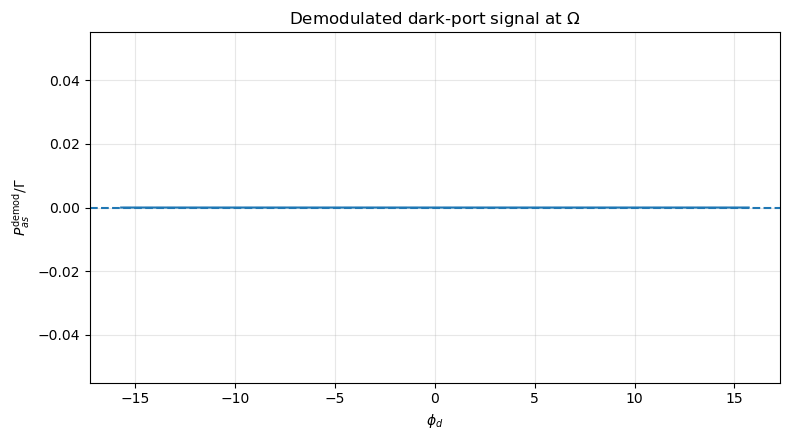

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

c = 299792458.0
Lx = 5.0   # [m]
Ly = 5     # [m]
Lbar = 0.5 * (Lx + Ly)

Omega = 2 * np.pi * 10e6   # 10 MHz
E0 = 1.0
Gamma = 1.0

# sweep phi_d
phi_d = np.linspace(-5*np.pi, 5*np.pi, 4000)

# RF differential phase
varphi_d = Omega * (Lx - Ly) / c

# demodulation phase
phi_a = -Omega * Lbar / c

# demodulated signal / Gamma
Pdemod_over_Gamma = (
    -0.5 * E0**2
    * np.sin(phi_d)
    * np.sin(varphi_d / 2)
    * np.cos(phi_a + Omega * Lbar / c)
)

print(f"varphi_d = {varphi_d:.6e} rad")

plt.figure(figsize=(8, 4.5))
plt.plot(phi_d, Pdemod_over_Gamma)
plt.axhline(0, linestyle='--')
plt.xlabel(r'$\phi_d$')
plt.ylabel(r'$P_{as}^{\rm demod}/\Gamma$')
plt.title(r'Demodulated dark-port signal at $\Omega$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Fabry-Perot Michelson Interferometer (FPMI)

We investigated *compound interferometers* in class when we studied the coupled-cavity.\
Here we combine our Michelson interferometer with Fabry-Perot interferometers forming the arms,
forming the Fabry-Perot Michelson Interferometer (FPMI) in a configuration similar to LIGO.

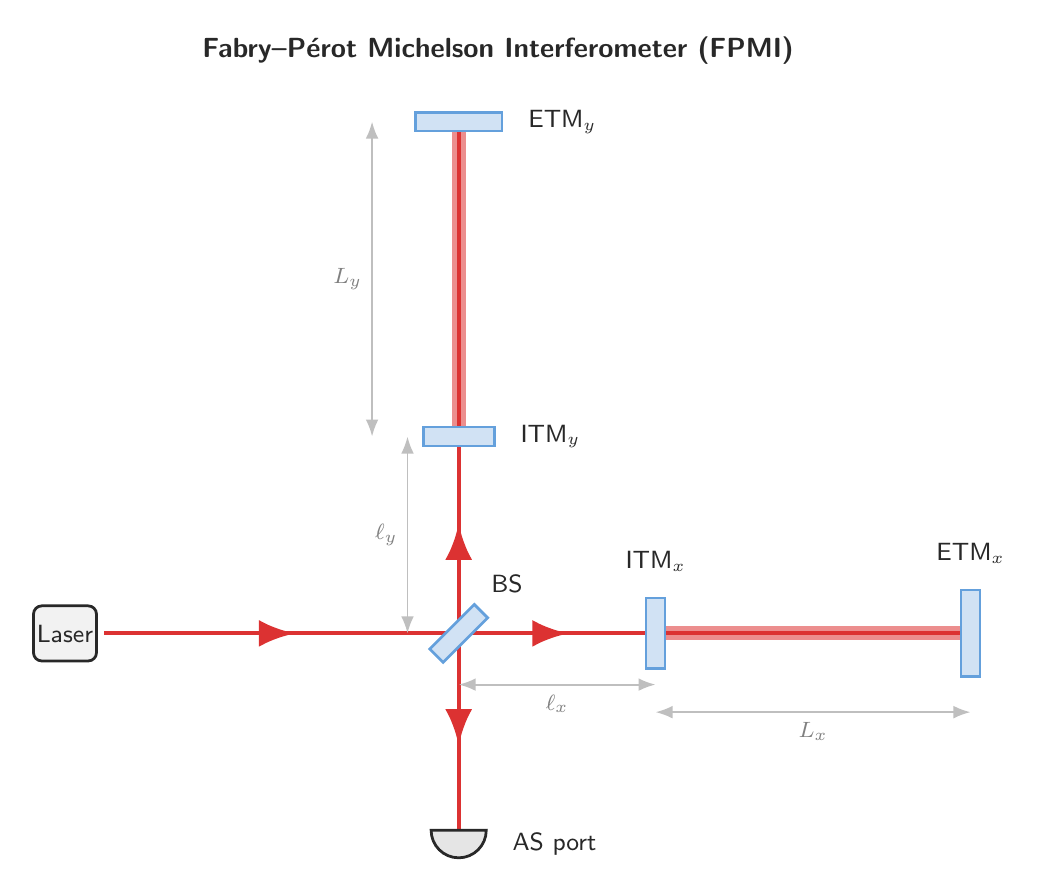

## Adjacency Matrix

Form an adjacency matrix for the FPMI interferometer.

I recommend using $\phi_x = k \ell_x$ and $\phi_y = k \ell_y$ for the short Michelson arms,\
and $\Phi_x = k L_x$ and $\Phi_y = k L_y$ for the Fabry-Perot arm lengths.




$$
\mathbf x =
\begin{bmatrix}
E_{\mathrm{BS}\to x} \\
E_{x\to \mathrm{ITM}_x} \\
E_{\mathrm{ITM}_x\to x} \\
E_{\mathrm{ITM}_x\to \mathrm{ETM}_x} \\
E_{\mathrm{ETM}_x\to \mathrm{ITM}_x} \\
E_{x\to \mathrm{BS}} \\
E_{\mathrm{BS}\to y} \\
E_{y\to \mathrm{ITM}_y} \\
E_{\mathrm{ITM}_y\to y} \\
E_{\mathrm{ITM}_y\to \mathrm{ETM}_y} \\
E_{\mathrm{ETM}_y\to \mathrm{ITM}_y} \\
E_{y\to \mathrm{BS}}
\end{bmatrix}.
$$

$$
\mathbb A=
\begin{bmatrix}
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\[4pt]

e^{-i\phi_x} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\[4pt]

0 & r_{1x} & 0 & 0 & i t_{1x} & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\[4pt]

0 & i t_{1x} & 0 & 0 & r_{1x} & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\[4pt]

0 & 0 & 0 & r_{2x}e^{-2i\Phi_x} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\[4pt]

0 & 0 & e^{-i\phi_x} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\[4pt]

0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\[4pt]

0 & 0 & 0 & 0 & 0 & 0 & e^{-i\phi_y} & 0 & 0 & 0 & 0 & 0 \\[4pt]

0 & 0 & 0 & 0 & 0 & 0 & 0 & r_{1y} & 0 & 0 & i t_{1y} & 0 \\[4pt]

0 & 0 & 0 & 0 & 0 & 0 & 0 & i t_{1y} & 0 & 0 & r_{1y} & 0 \\[4pt]

0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & r_{2y}e^{-2i\Phi_y} & 0 & 0 \\[4pt]

0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & e^{-i\phi_y} & 0 & 0 & 0
\end{bmatrix}.
$$

$$
\mathbf x = \mathbb A\,\mathbf x + \mathbf s\,E_{\mathrm{in}}.
$$




$$
\textbf{Definitions}
$$

$$
\phi_x = k \ell_x,
\qquad
\phi_y = k \ell_y,
\qquad
\Phi_x = k L_x,
\qquad
\Phi_y = k L_y .
$$

$$
\tilde{\mathbf{E}}
=
\begin{bmatrix}
E_{\mathrm{in}} \\
E_{\mathrm{BS}\to x} \\
E_{x\to \mathrm{ITM}_x} \\
E_{\mathrm{ITM}_x\to x} \\
E_{x\to \mathrm{BS}} \\
E_{\mathrm{ITM}_x\to \mathrm{ETM}_x} \\
E_{\mathrm{ETM}_x\to \mathrm{ITM}_x} \\
E_{\mathrm{BS}\to y} \\
E_{y\to \mathrm{ITM}_y} \\
E_{\mathrm{ITM}_y\to y} \\
E_{y\to \mathrm{BS}} \\
E_{\mathrm{ITM}_y\to \mathrm{ETM}_y} \\
E_{\mathrm{ETM}_y\to \mathrm{ITM}_y} \\
E_{\mathrm{REFL}} \\
E_{\mathrm{AS}}
\end{bmatrix},
\begin{bmatrix}
1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\[4pt]

t_{\mathrm{bs}} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\[4pt]

0 & e^{-i\phi_x} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\[4pt]

0 & 0 & r_{1x} & 0 & 0 & 0 & i t_{1x} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\[4pt]

0 & 0 & 0 & e^{-i\phi_x} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\[4pt]

0 & 0 & i t_{1x} & 0 & 0 & 0 & r_{1x} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\[4pt]

0 & 0 & 0 & 0 & 0 & r_{2x} e^{-2 i \Phi_x} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\[4pt]

i r_{\mathrm{bs}} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\[4pt]

0 & 0 & 0 & 0 & 0 & 0 & 0 & e^{-i\phi_y} & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\[4pt]

0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & r_{1y} & 0 & 0 & 0 & i t_{1y} & 0 & 0 \\[4pt]

0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & e^{-i\phi_y} & 0 & 0 & 0 & 0 & 0 \\[4pt]

0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & i t_{1y} & 0 & 0 & 0 & r_{1y} & 0 & 0 \\[4pt]

0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & r_{2y} e^{-2 i \Phi_y} & 0 & 0 & 0 \\[4pt]

0 & 0 & 0 & 0 & t_{\mathrm{bs}} & 0 & 0 & 0 & 0 & 0 & i r_{\mathrm{bs}} & 0 & 0 & 0 & 0 \\[4pt]

0 & 0 & 0 & 0 & i r_{\mathrm{bs}} & 0 & 0 & 0 & 0 & 0 & t_{\mathrm{bs}} & 0 & 0 & 0 & 0
\end{bmatrix}.
$$

## Antisymmetric Port Field Derivations

Find the $\dfrac{E_\mathrm{as}}{E_\mathrm{in}}$ transfer function by inverting the adjacency matrix.

You may also derive the FPMI response by using the compound interferometer technique, 
by letting the common Michelson X-arm reflection $r_x \rightarrow r_\mathrm{FP}(\Phi_x) = \dfrac{E_\mathrm{refl}}{E_\mathrm{in}}$.\
Does this derivation agree with your result from the adjacency matrix?



I used mathematica to invert the adjacency matrix.


$$
(\mathbb I-\mathbb A)\mathbf x = \mathbf s\,E_{\mathrm{in}}
$$


$$
E_{\mathrm{refl}}
=
r_{\mathrm{bs}}\,E_{x\to \mathrm{BS}}
+
t_{\mathrm{bs}}\,E_{y\to \mathrm{BS}},
$$

$$
E_{\mathrm{AS}}
=
t_{\mathrm{bs}}\,E_{x\to \mathrm{BS}}
-
r_{\mathrm{bs}}\,E_{y\to \mathrm{BS}}.
$$

$$
\begin{bmatrix}
E_{\mathrm{refl}} \\
E_{\mathrm{AS}}
\end{bmatrix}
=
\mathbb B\,\mathbf x,
\qquad
\mathbb B=
\begin{bmatrix}
0 & 0 & 0 & 0 & 0 & r_{\mathrm{bs}} & 0 & 0 & 0 & 0 & 0 & t_{\mathrm{bs}} \\[4pt]
0 & 0 & 0 & 0 & 0 & t_{\mathrm{bs}} & 0 & 0 & 0 & 0 & 0 & -r_{\mathrm{bs}}
\end{bmatrix}.
$$

$$
\begin{bmatrix}
E_{\mathrm{refl}} \\
E_{\mathrm{AS}}
\end{bmatrix}
=
\mathbb B(\mathbb I-\mathbb A)^{-1}\mathbf s\,E_{\mathrm{in}}.
$$

$$
\begin{bmatrix}
\dfrac{E_{\mathrm{refl}}}{E_{\mathrm{in}}} \\
\dfrac{E_{\mathrm{AS}}}{E_{\mathrm{in}}}
\end{bmatrix}
=
\mathbb B(\mathbb I-\mathbb A)^{-1}\mathbf s .
$$
$$
\frac{E_{x\to \mathrm{BS}}}{E_{\mathrm{in}}}
=
t_{\mathrm{bs}}\,e^{-2i\phi_x}
\left(
r_{1x}
-
\frac{t_{1x}^2 r_{2x} e^{-2i\Phi_x}}
     {1-r_{1x}r_{2x}e^{-2i\Phi_x}}
\right)
$$

$$
\frac{E_{y\to \mathrm{BS}}}{E_{\mathrm{in}}}
=
r_{\mathrm{bs}}\,e^{-2i\phi_y}
\left(
r_{1y}
-
\frac{t_{1y}^2 r_{2y} e^{-2i\Phi_y}}
     {1-r_{1y}r_{2y}e^{-2i\Phi_y}}
\right)
$$

$$
\frac{E_{\mathrm{refl}}}{E_{\mathrm{in}}}
=
r_{\mathrm{bs}}t_{\mathrm{bs}}
\left[
e^{-2i\phi_x}
\left(
r_{1x}
-
\frac{t_{1x}^2 r_{2x} e^{-2i\Phi_x}}
     {1-r_{1x}r_{2x}e^{-2i\Phi_x}}
\right)
+
e^{-2i\phi_y}
\left(
r_{1y}
-
\frac{t_{1y}^2 r_{2y} e^{-2i\Phi_y}}
     {1-r_{1y}r_{2y}e^{-2i\Phi_y}}
\right)
\right]
$$

$$
\frac{E_{\mathrm{AS}}}{E_{\mathrm{in}}}
=
t_{\mathrm{bs}}^2 e^{-2i\phi_x}
\left(
r_{1x}
-
\frac{t_{1x}^2 r_{2x} e^{-2i\Phi_x}}
     {1-r_{1x}r_{2x}e^{-2i\Phi_x}}
\right)
-
r_{\mathrm{bs}}^2 e^{-2i\phi_y}
\left(
r_{1y}
-
\frac{t_{1y}^2 r_{2y} e^{-2i\Phi_y}}
     {1-r_{1y}r_{2y}e^{-2i\Phi_y}}
\right)
$$




## Simplifications to $E_\mathrm{as}$

At this point, you may simplify $E_\mathrm{as}$ and change the basis using 
\begin{align}
\Phi_x &= \Phi_c + \Phi_d\\
\Phi_y &= \Phi_c - \Phi_d\\
\phi_x &= 0\\
\phi_y &= 0\\
r_\mathrm{bs} = t_\mathrm{bs} &= \dfrac{1}{\sqrt{2}}\\
r_\mathrm{itmx} &= r_\mathrm{itmy}\\
r_\mathrm{etmx} &= r_\mathrm{etmy}
\end{align}
The above assumes the short Michelson is always perfectly tuned, and the beamsplitter is ideal, and the Fabry-Perot arms are ideally balanced.



$$
\frac{E_{\mathrm{AS}}}{E_{\mathrm{in}}}
=
\frac{1}{2}
\left[
\left(
r_{\mathrm{itmx}}
-
\frac{t_{\mathrm{itmx}}^{\,2}\,r_{\mathrm{etmx}}\,e^{-2i(\Phi_c+\Phi_d)}}
{1-r_{\mathrm{itmx}}\,r_{\mathrm{etmx}}\,e^{-2i(\Phi_c+\Phi_d)}}
\right)
-
\left(
r_{\mathrm{itmy}}
-
\frac{t_{\mathrm{itmy}}^{\,2}\,r_{\mathrm{etmy}}\,e^{-2i(\Phi_c-\Phi_d)}}
{1-r_{\mathrm{itmy}}\,r_{\mathrm{etmy}}\,e^{-2i(\Phi_c-\Phi_d)}}
\right)
\right]
$$

$$
\frac{E_{\mathrm{refl}}}{E_{\mathrm{in}}}
=
\frac{1}{2}
\left[
\left(
r_{\mathrm{itmx}}
-
\frac{t_{\mathrm{itmx}}^{\,2}\,r_{\mathrm{etmx}}\,e^{-2i(\Phi_c+\Phi_d)}}
{1-r_{\mathrm{itmx}}\,r_{\mathrm{etmx}}\,e^{-2i(\Phi_c+\Phi_d)}}
\right)
+
\left(
r_{\mathrm{itmy}}
-
\frac{t_{\mathrm{itmy}}^{\,2}\,r_{\mathrm{etmy}}\,e^{-2i(\Phi_c-\Phi_d)}}
{1-r_{\mathrm{itmy}}\,r_{\mathrm{etmy}}\,e^{-2i(\Phi_c-\Phi_d)}}
\right)
\right]
$$

## Interpretation

Plot the real and imaginary parts of $\dfrac{E_\mathrm{as}}{E_\mathrm{in}}$ as a function of $\Phi_d$.

Compare to the normal Michelson solution for the AS port.\
Do the Fabry-Perot arms enhance our sensitivity to differential displacement $\Phi_d$?

You may substitute in a moderate finesse Fabry-Perot cavity values
\begin{align}
\ell_x = \ell_y &= 5~\mathrm{m}\\
L_x = L_y &= 4000~\mathrm{m}\\
T_\mathrm{etmx} = T_\mathrm{etmy} &= 0\\
T_\mathrm{itmx} = T_\mathrm{itmy} &= 10\% \\
\end{align}


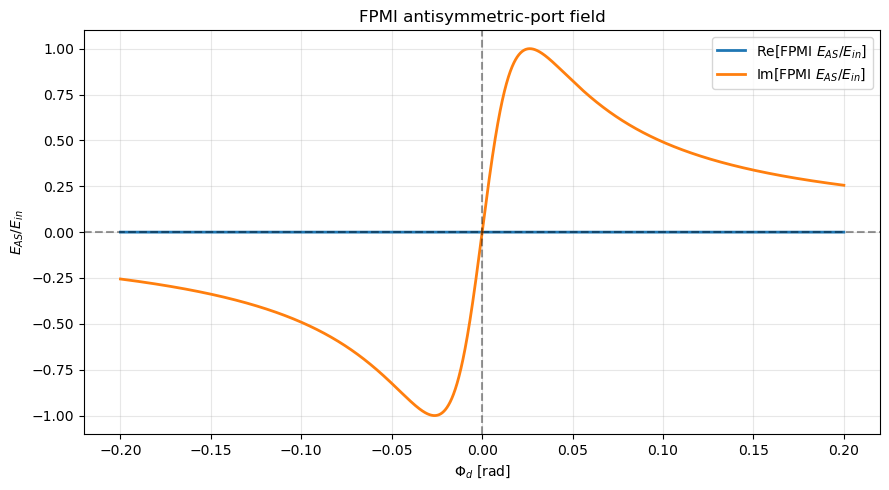

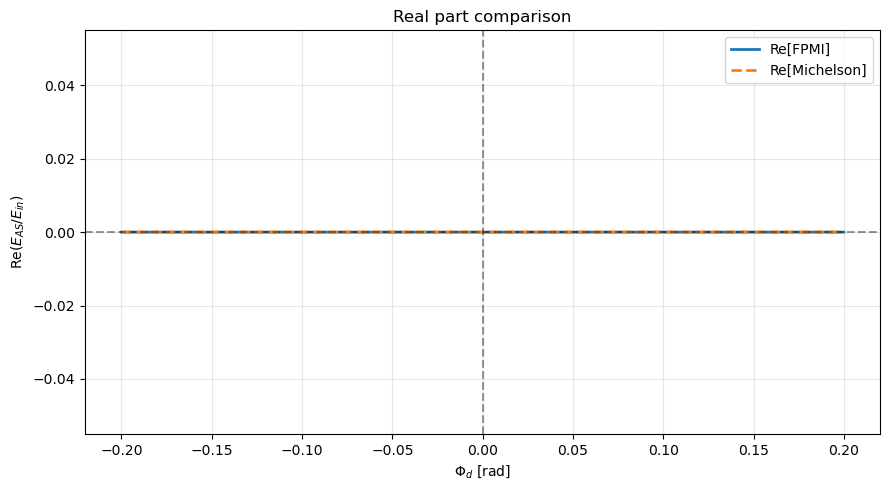

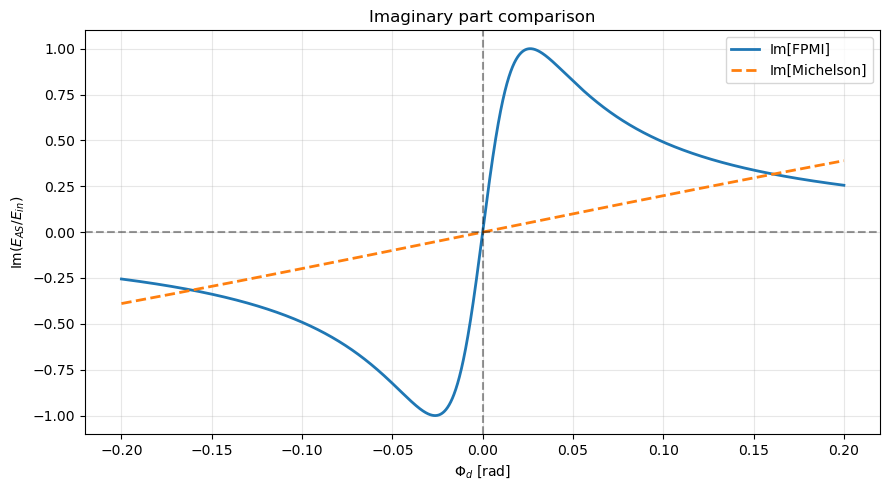

In [28]:
import numpy as np
import matplotlib.pyplot as plt


ell_x = ell_y = 5.0          # [m]
L_x = L_y = 4000.0           #  [m]

T_itmx = T_itmy = 0.10       # ITM power transmissivity
T_etmx = T_etmy = 0.00       # ETM power transmissivity

# Amplitude coefficients
t_itmx = np.sqrt(T_itmx)
t_itmy = np.sqrt(T_itmy)
r_itmx = np.sqrt(1.0 - T_itmx)
r_itmy = np.sqrt(1.0 - T_itmy)

t_etmx = np.sqrt(T_etmx)
t_etmy = np.sqrt(T_etmy)
r_etmx = np.sqrt(1.0 - T_etmx)
r_etmy = np.sqrt(1.0 - T_etmy)

# 50/50 beamsplitter
r_bs = 1 / np.sqrt(2)
t_bs = 1 / np.sqrt(2)


Phi_c = 0.0 # common resonancce

# Sweep differential arm phase
Phi_d = np.linspace(-0.2, 0.2, 4000)   # radians


exp_x = np.exp(-2j * (Phi_c + Phi_d))
exp_y = np.exp(-2j * (Phi_c - Phi_d))

arm_x = r_itmx - (t_itmx**2 * r_etmx * exp_x) / (1.0 - r_itmx * r_etmx * exp_x)
arm_y = r_itmy - (t_itmy**2 * r_etmy * exp_y) / (1.0 - r_itmy * r_etmy * exp_y)

Eas_fpmi = (t_bs**2) * arm_x - (r_bs**2) * arm_y


Eas_mich = 0.5 * (np.exp(-2j * (Phi_c - Phi_d)) - np.exp(-2j * (Phi_c + Phi_d)))


dPhi = Phi_d[1] - Phi_d[0]
idx0 = np.argmin(np.abs(Phi_d))

dE_fpmi = np.gradient(Eas_fpmi, dPhi)
dE_mich = np.gradient(Eas_mich, dPhi)




plt.figure(figsize=(9, 5))
plt.plot(Phi_d, Eas_fpmi.real, label='Re[FPMI $E_{AS}/E_{in}$]', linewidth=2)
plt.plot(Phi_d, Eas_fpmi.imag, label='Im[FPMI $E_{AS}/E_{in}$]', linewidth=2)
plt.axhline(0, color='k', linestyle='--', alpha=0.4)
plt.axvline(0, color='k', linestyle='--', alpha=0.4)
plt.xlabel(r'$\Phi_d$ [rad]')
plt.ylabel(r'$E_{AS}/E_{in}$')
plt.title('FPMI antisymmetric-port field')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(Phi_d, Eas_fpmi.real, label='Re[FPMI]', linewidth=2)
plt.plot(Phi_d, Eas_mich.real, label='Re[Michelson]', linewidth=2, linestyle='--')
plt.axhline(0, color='k', linestyle='--', alpha=0.4)
plt.axvline(0, color='k', linestyle='--', alpha=0.4)
plt.xlabel(r'$\Phi_d$ [rad]')
plt.ylabel(r'$\mathrm{Re}(E_{AS}/E_{in})$')
plt.title('Real part comparison')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(Phi_d, Eas_fpmi.imag, label='Im[FPMI]', linewidth=2)
plt.plot(Phi_d, Eas_mich.imag, label='Im[Michelson]', linewidth=2, linestyle='--')
plt.axhline(0, color='k', linestyle='--', alpha=0.4)
plt.axvline(0, color='k', linestyle='--', alpha=0.4)
plt.xlabel(r'$\Phi_d$ [rad]')
plt.ylabel(r'$\mathrm{Im}(E_{AS}/E_{in})$')
plt.title('Imaginary part comparison')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Questions: **Compare to the normal Michelson solution for the AS port.\ Do the Fabry-Perot arms enhance our sensitivity to differential displacement $\Phi_d$?**

Compared to a plain Michelson, the Fabry–Perot Michelson is more sensitive to small differential phase shifts $\Phi_d$. This should be because of the cavity phase amplification.